In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv('/content/Advertising (2).csv')
df

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [4]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.tail()

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [6]:
df.shape

(200, 5)

In [7]:
df.columns

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [9]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [10]:
df = df.drop("Unnamed: 0", axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [11]:
df.isnull().sum()

,0
TV,0
radio,0
newspaper,0
sales,0


In [12]:
df.duplicated().sum()

np.int64(0)

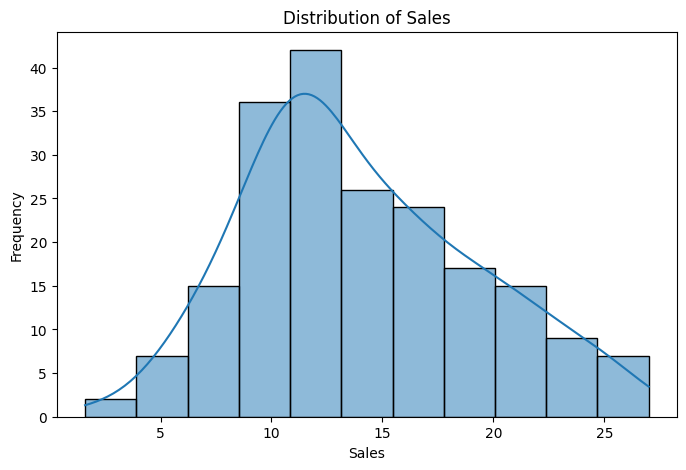

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df["sales"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

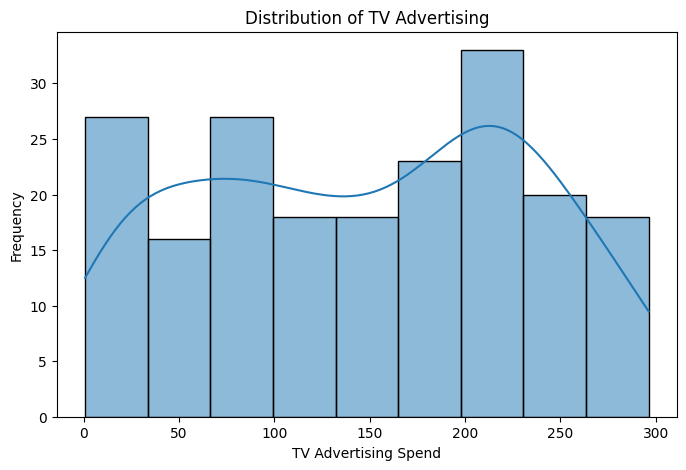

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["TV"], kde=True)
plt.title("Distribution of TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Frequency")
plt.show()

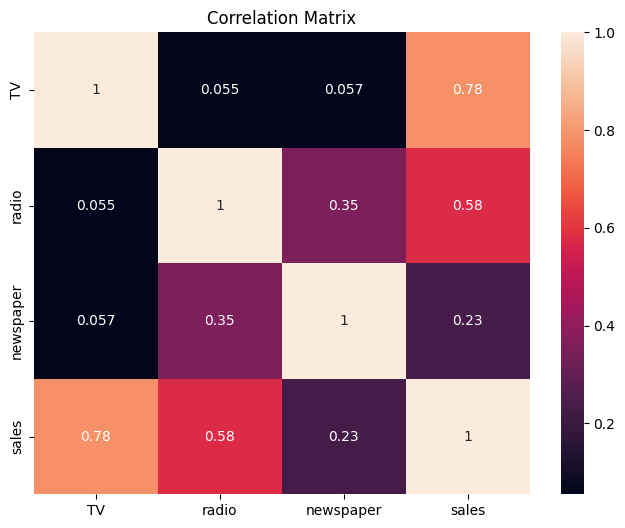

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

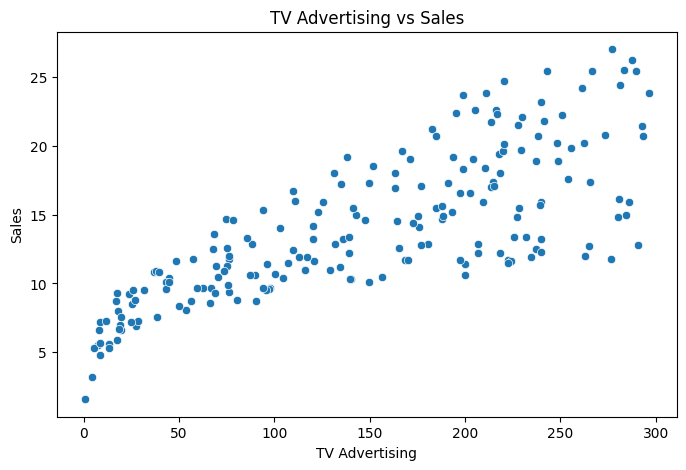

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="TV", y="sales", data=df)
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.show()

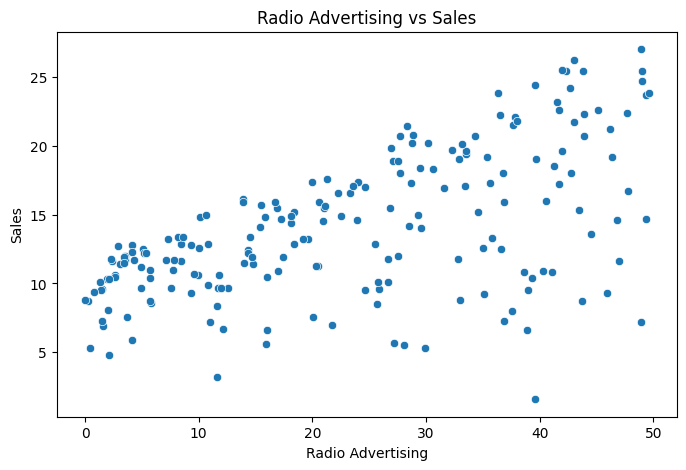

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="radio", y="sales", data=df)
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")
plt.show()

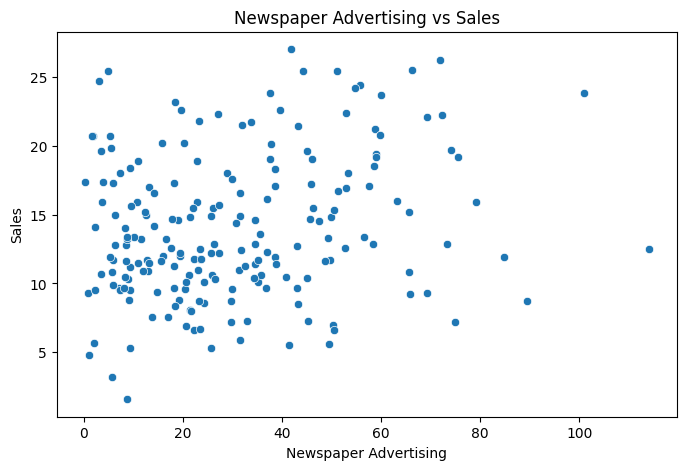

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="newspaper", y="sales", data=df)
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")
plt.show()

In [20]:
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

In [21]:
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
      TV  radio  newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target (y):
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: sales, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [25]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)
print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [27]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})
comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [29]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912


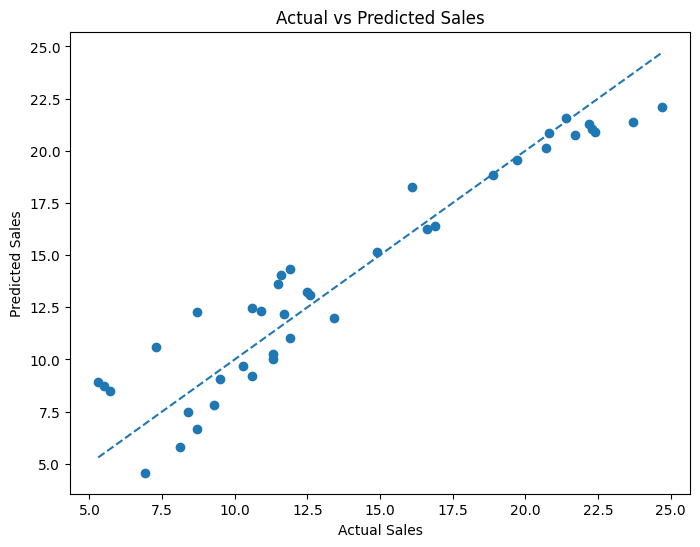

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

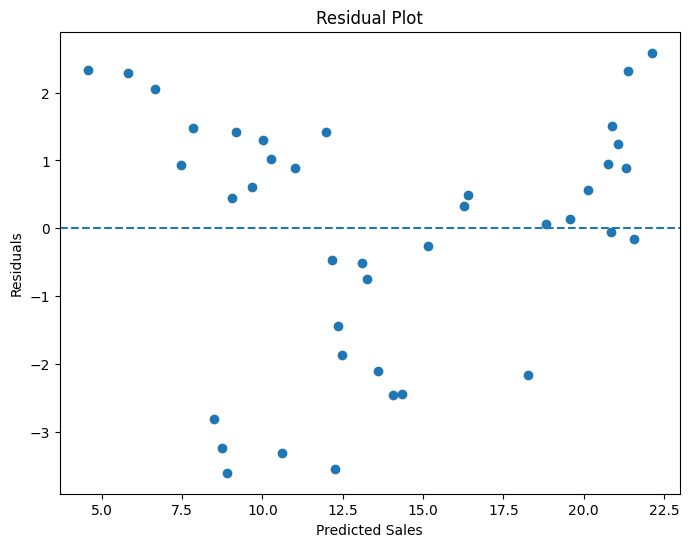

In [31]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

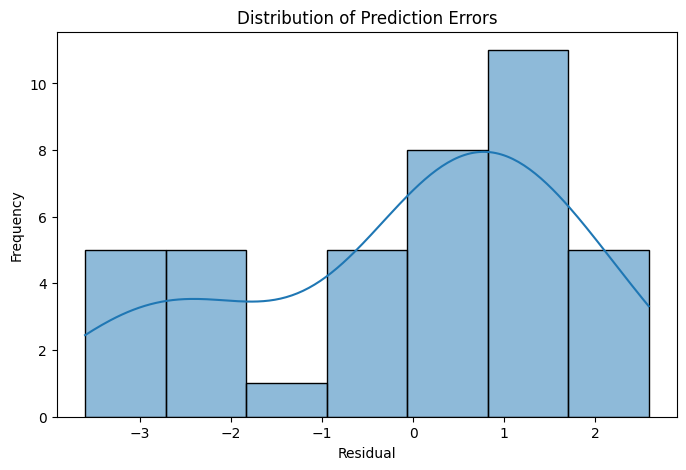

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [33]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients

,Feature,Coefficient
0,TV,0.044730
1,radio,0.189195
2,newspaper,0.002761


In [34]:
print("Intercept:", model.intercept_)

Intercept: 2.979067338122629


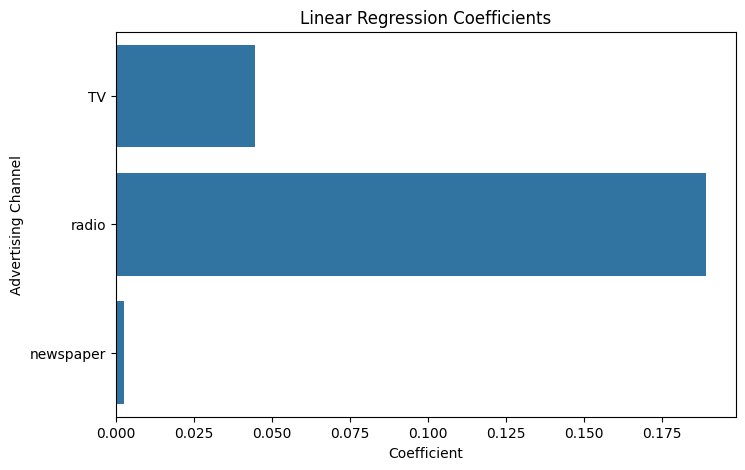

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coefficients
)
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Advertising Channel")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeRegressor

In [37]:
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [38]:
dt_pred = dt_model.predict(X_test)

In [39]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

MAE : 1.1943504273504275
MSE : 2.6973608080448925
RMSE: 1.6423643956335916
R² Score: 0.9145420249224665


In [40]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, dt_mae],
    "MSE": [mse, dt_mse],
    "RMSE": [rmse, dt_rmse],
    "R² Score": [r2, dt_r2]
})
model_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.460757,3.174097,1.781600,0.899438
1,Decision Tree,1.194350,2.697361,1.642364,0.914542


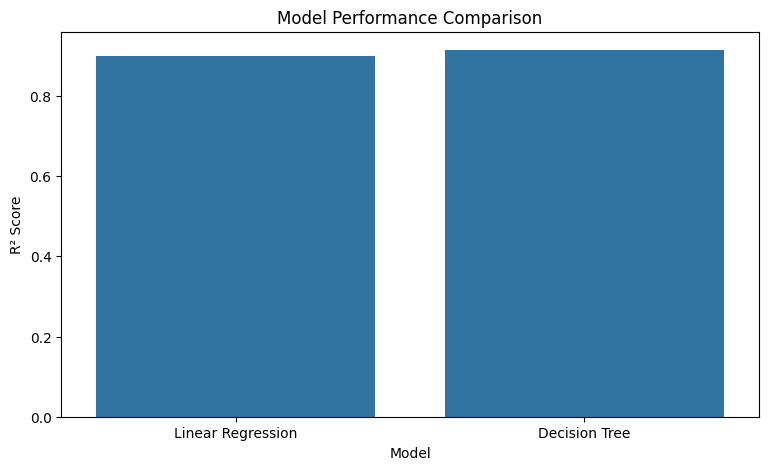

In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="R² Score"
)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

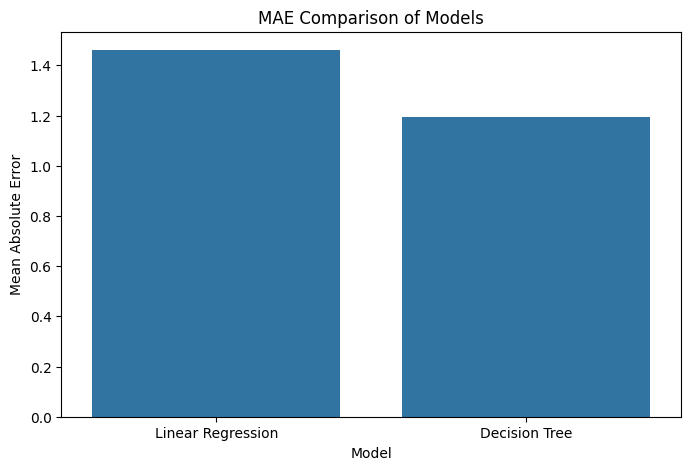

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="MAE"
)
plt.title("MAE Comparison of Models")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.show()

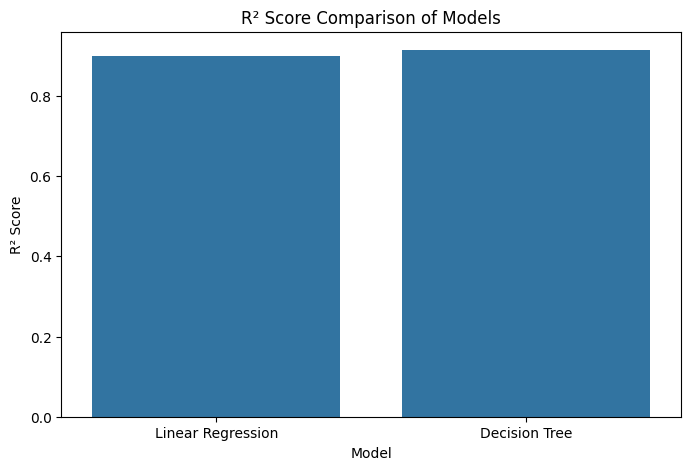

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="R² Score"
)
plt.title("R² Score Comparison of Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.show()

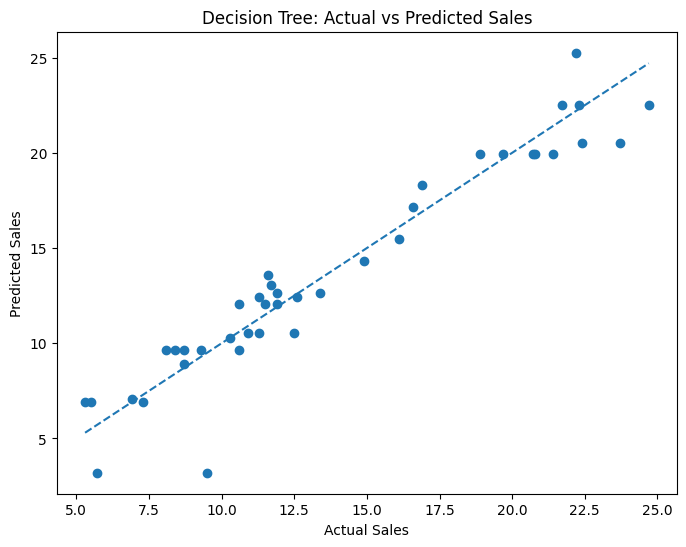

In [44]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("Decision Tree: Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

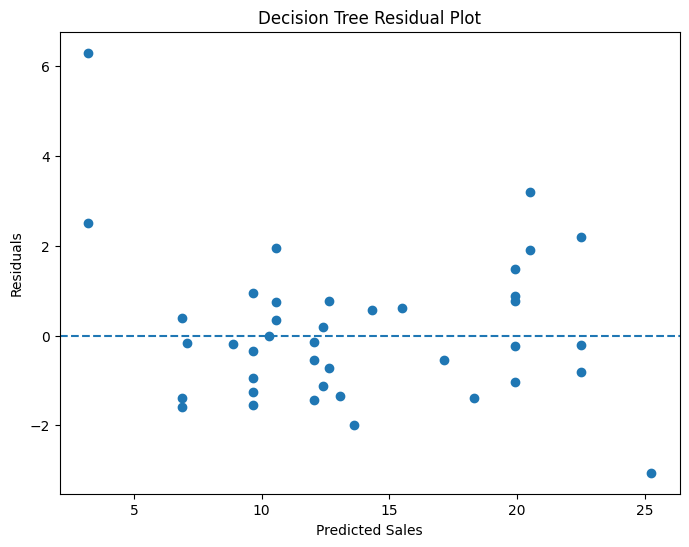

In [45]:
dt_residuals = y_test - dt_pred
plt.figure(figsize=(8, 6))
plt.scatter(dt_pred, dt_residuals)
plt.axhline(y=0, linestyle="--")
plt.title("Decision Tree Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.show()

In [46]:
dt_train_pred = dt_model.predict(X_train)
train_r2 = r2_score(y_train, dt_train_pred)
test_r2 = r2_score(y_test, dt_pred)
print("Training R² Score:", train_r2)
print("Testing R² Score :", test_r2)

Training R² Score: 0.9851290275048047
Testing R² Score : 0.9145420249224665


In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
0,TV,0.611197
1,radio,0.377646
2,newspaper,0.011158


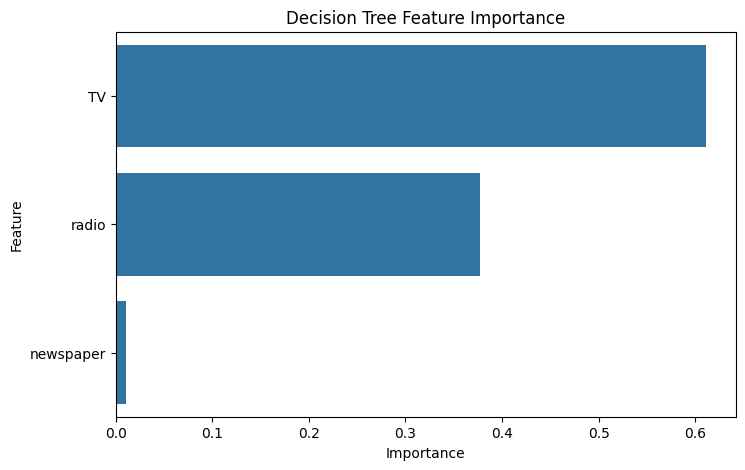

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()